In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import json
import importlib
import inspect
import argparse
import pandas as pd
import seaborn as sns

from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import OrderedDict

import numpy as np
import torch
from torch.utils.data import DataLoader

from import_model import import_model
from import_dataset import import_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
train_session_dir = "train_sessions/EncoderDecoderTransformer_20250704_150947"

In [4]:
json_to_inference = os.path.join(train_session_dir,"args.json")
with open(json_to_inference, 'r') as f:
    data = json.load(f)

In [5]:
model_name = data["model_name"]

train_pred_name = f'{model_name}_train_pred_series.pt'
val_pred_name = f'{model_name}_val_pred_series.pt'

train_pred_path = os.path.join(train_session_dir, train_pred_name)
val_pred_path = os.path.join(train_session_dir, val_pred_name)

target_and_pred_names = [train_pred_name, val_pred_name]
model_pt_name = [x for x in os.listdir(train_session_dir) if x.endswith(".pt") and x not in target_and_pred_names][0]
model_pt_path = os.path.join(train_session_dir, model_pt_name)

In [6]:
args = argparse.Namespace(**data)

base_dataset_kwargs = {"input_coins": args.input_coins, "input_features": args.input_features, "output_coins": args.output_coins,
"output_features": args.output_features, "input_window": args.input_window, "output_window": args.output_window,
"augmentation_noise_std": args.augmentation_noise_std, "augmentation_constant_c": args.augmentation_constant_c, "augmentation_scale_s": args.augmentation_scale_s,
"transform_name":args.transform_name, "output_distribution": args.output_distribution, "n_quantiles": args.n_quantiles, "train_session_dir": train_session_dir}

inference_val_dataset_kwargs = {**base_dataset_kwargs, "csv_path": args.val_csv_path, "augmentation_p": 0, "training_dataset":0}
inference_val_dataset = import_dataset(args.dataset_name, **inference_val_dataset_kwargs)
inference_val_loader = DataLoader(inference_val_dataset, batch_size=args.batch_size, shuffle=False)

inference_train_dataset_kwargs = {**base_dataset_kwargs, "csv_path": args.train_csv_path, "augmentation_p": 0, "training_dataset":1}
inference_train_dataset = import_dataset(args.dataset_name, **inference_train_dataset_kwargs)
inference_train_loader = DataLoader(inference_train_dataset, batch_size=args.batch_size, shuffle=False)

input_cols = [f'{c}_{f}' for c in args.input_coins for f in args.input_features]
output_cols = [f'{c}_{f}' for c in args.output_coins for f in args.output_features]
output_col_indices_in_input_cols = [input_cols.index(col) for col in output_cols]
target_coin_indices = [args.input_coins.index(c) for c in args.output_coins]

model_kwargs = {"input_features": len(args.input_coins)*len(args.input_features), "output_features": len(args.output_coins)*len(args.output_features),
"input_window": args.input_window, "output_window": args.output_window,
"dropout": args.dropout, "num_layers": args.num_layers,
"hidden_dim": args.hidden_dim, "num_heads": args.num_heads,
"teacher_forcing_ratio": args.teacher_forcing_ratio, "input_cols":input_cols, "output_cols":output_cols,
"target_coin_indices": target_coin_indices, "output_col_indices_in_input_cols": output_col_indices_in_input_cols,
"device": device}

In [7]:
model = import_model(args.model_name, **model_kwargs)
model.load_state_dict(torch.load(model_pt_path, weights_only=True))

<All keys matched successfully>

In [8]:
from datetime import datetime

# MODEL'S PREDICTIONS
# WILL BE USED TO CHECK HOW GOOD MODELS PREDICTIONS ARE, ALSO WILL BE RE-SCALE TO REAL PRICE DATA AND CHECK THE DIFFERENCE THE TRANSFORMS CAUSED
train_pred_series = torch.load(train_pred_path)
val_pred_series = torch.load(val_pred_path)

print("train_pred_series:", train_pred_series.shape)
print("val_pred_series:", val_pred_series.shape)

# DATA THE MODEL HAS SEEN IN THE TRAINING LOOP AFTER THE PREPROCESSING
# WILL BE USED TO SHOW HOW GOOD ARE MODELS PREDICTIONS, ALSO WILL BE PLOTTED AS THE REAL PRICE TO CHECK THE DIFFERENCE PREPROCESSING CAUSE
train_learned_dataframe_crop = inference_train_dataset.df.iloc[data["input_window"]:]
val_learned_dataframe_crop = inference_val_dataset.df.iloc[data["input_window"]:]

print("train_learned_dataframe_crop:", train_learned_dataframe_crop.shape)
print("val_learned_dataframe_crop:", val_learned_dataframe_crop.shape)

# REAL VALIDATION DATA
# WILL BE USED TO PLOT REAL PRICE GRAPH
train_df = pd.read_csv(data["train_csv_path"], index_col="open_time")
train_df_preds = train_df.loc[train_learned_dataframe_crop.index]
# we take the data["input_window"]th data as the initial price instead of data["input_window"]-1
# it's because we are shifting the dates 1 interval back during the preprocessing, so the first day is kinda wasted for the lof return computations
# and so the initial price is also shifted one interval further than it would be at an unshifted dataset
t1 = datetime.strptime(train_learned_dataframe_crop.index[0], "%Y-%m-%d %H:%M:%S")
t2 = datetime.strptime(train_learned_dataframe_crop.index[1], "%Y-%m-%d %H:%M:%S")
delta = t2 - t1
t0 = t1 - delta
train_initial_prices = torch.tensor(train_df.loc[str(t0)][:4].values).unsqueeze(0)

val_df = pd.read_csv(data["val_csv_path"], index_col="open_time")
val_df_preds = val_df.loc[val_learned_dataframe_crop.index]
t1 = datetime.strptime(val_learned_dataframe_crop.index[0], "%Y-%m-%d %H:%M:%S")
t2 = datetime.strptime(val_learned_dataframe_crop.index[1], "%Y-%m-%d %H:%M:%S")
delta = t2 - t1
t0 = t1 - delta
val_initial_prices = torch.tensor(val_df.loc[str(t0)][:4].values).unsqueeze(0)

print("train_df_preds:", train_df_preds.shape)
print("train_initial_prices:", train_initial_prices)
print("val_df_preds:", val_df_preds.shape)
print("val_initial_prices:", val_initial_prices)

train_pred_series: torch.Size([4, 364, 8])
val_pred_series: torch.Size([4, 64, 8])
train_learned_dataframe_crop: (371, 16)
val_learned_dataframe_crop: (71, 16)
train_df_preds: (371, 16)
train_initial_prices: tensor([[9005.0700, 8594.9800, 8582.5000, 9010.1100]], dtype=torch.float64)
val_df_preds: (71, 16)
val_initial_prices: tensor([[6372.2300, 6429.4100, 6341.0000, 6450.1200]], dtype=torch.float64)


## Predictions on the learned dataset

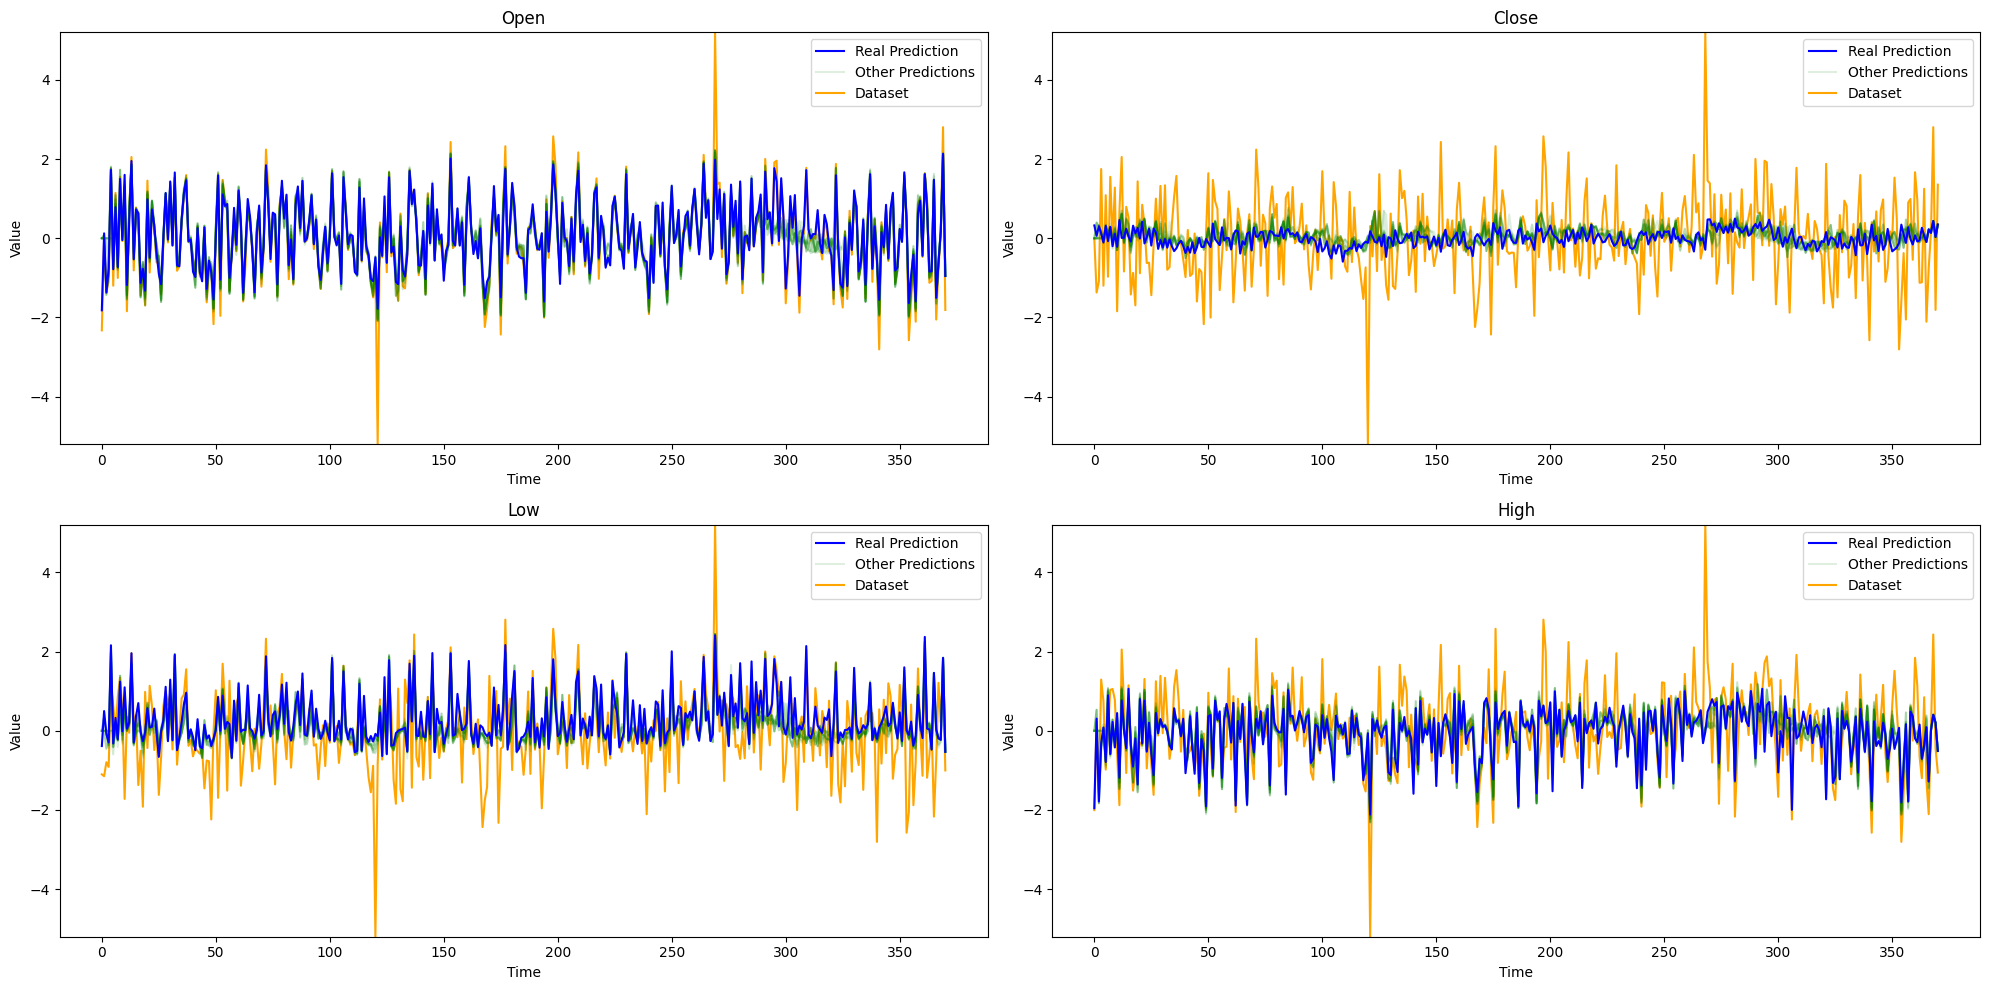

In [10]:
pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(train_pred_series.shape[0], trust), train_pred_series[:,:-1,trust], train_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    ground_truth = train_learned_dataframe_crop[inference_train_dataset.output_cols].values.T[i]
    plt.plot(ground_truth, label="Dataset", color="orange")
    for trust, pred_series_to_plot in reversed(list(enumerate(pred_series_with_different_trusts))):
        if trust == 0:
            plt.plot(pred_series_to_plot[i], label="Real Prediction", color="blue", alpha=1/(trust+1))
        else:
            plt.plot(pred_series_to_plot[i], label="Other Predictions", color="green", alpha=1/(trust+1))

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.ylim(ground_truth.min(), ground_truth.max())
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

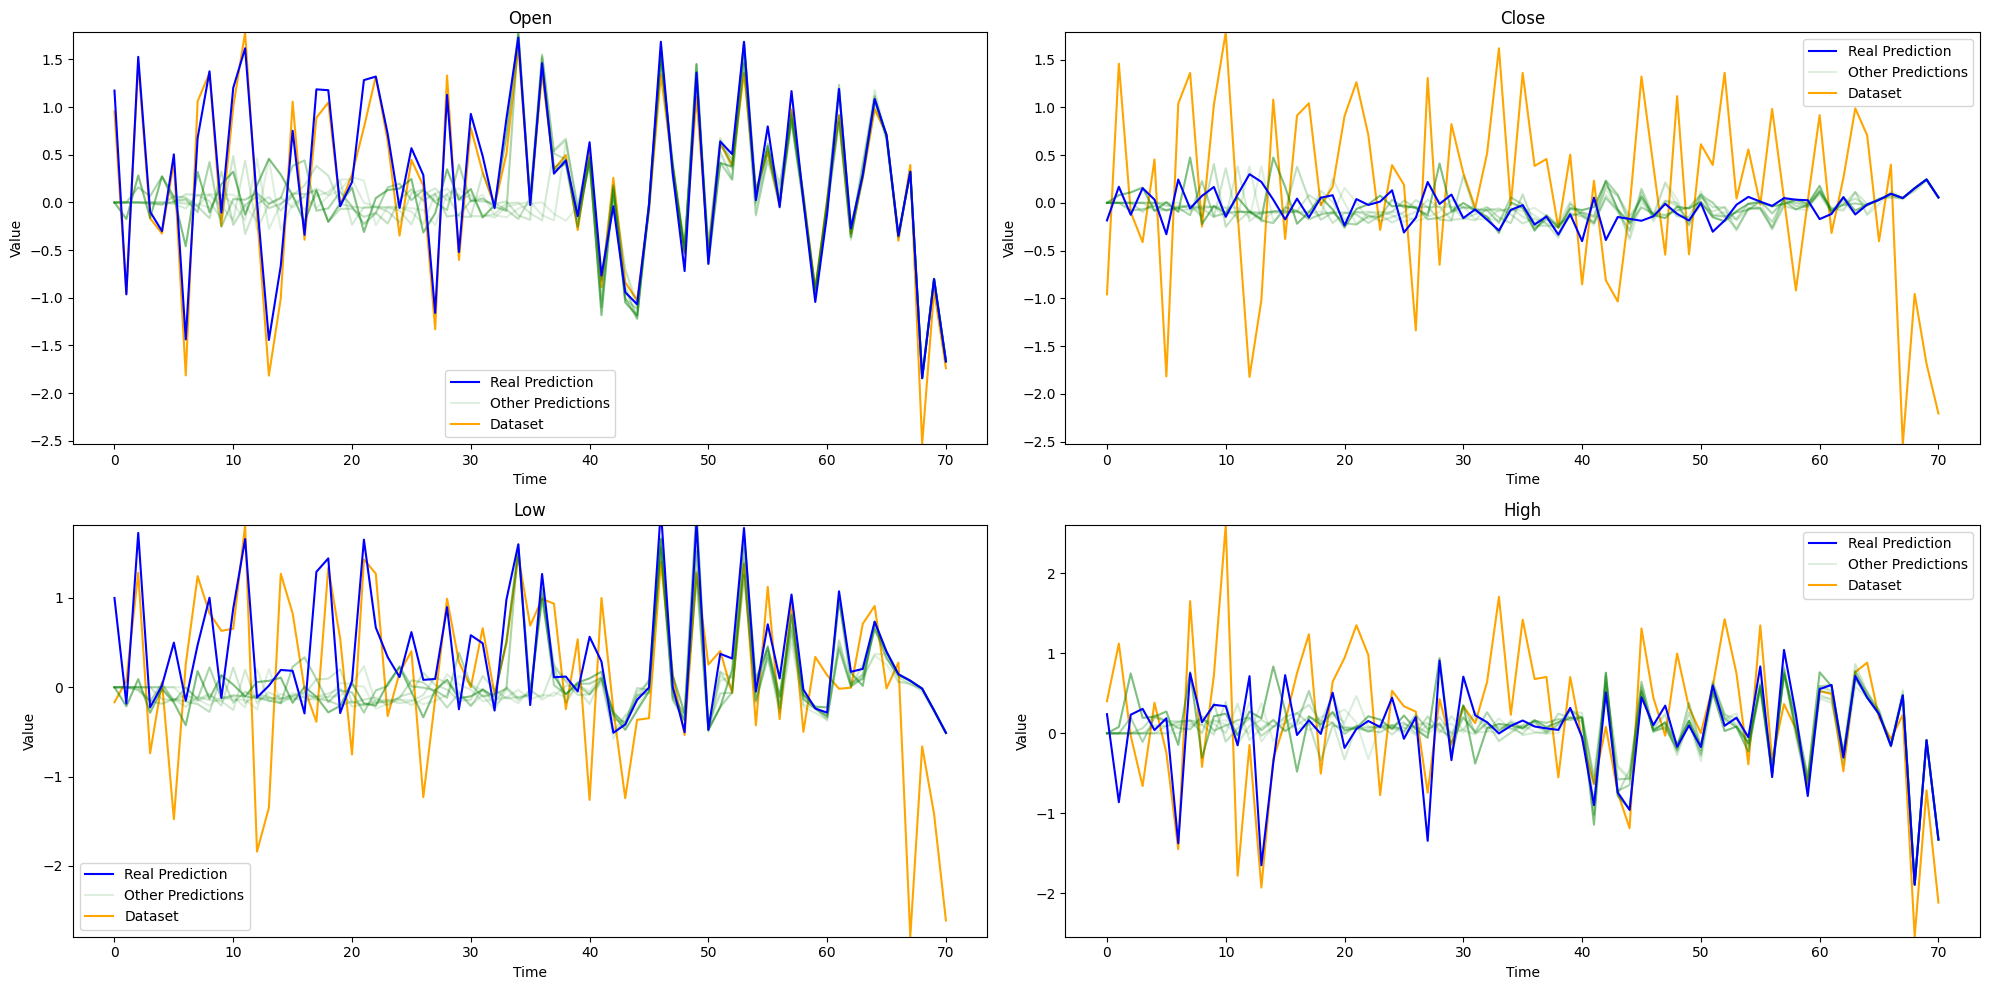

In [12]:
pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(val_pred_series.shape[0], trust), val_pred_series[:,:-1,trust], val_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    ground_truth = val_learned_dataframe_crop[inference_val_dataset.output_cols].values.T[i]
    plt.plot(ground_truth, label="Dataset", color="orange")
    for trust, pred_series_to_plot in reversed(list(enumerate(pred_series_with_different_trusts))):
        if trust == 0:
            plt.plot(pred_series_to_plot[i], label="Real Prediction", color="blue", alpha=1/(trust+1))
        else:
            plt.plot(pred_series_to_plot[i], label="Other Predictions", color="green", alpha=1/(trust+1))

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.ylim(ground_truth.min(), ground_truth.max())
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

# Line histograms on the learned datasets

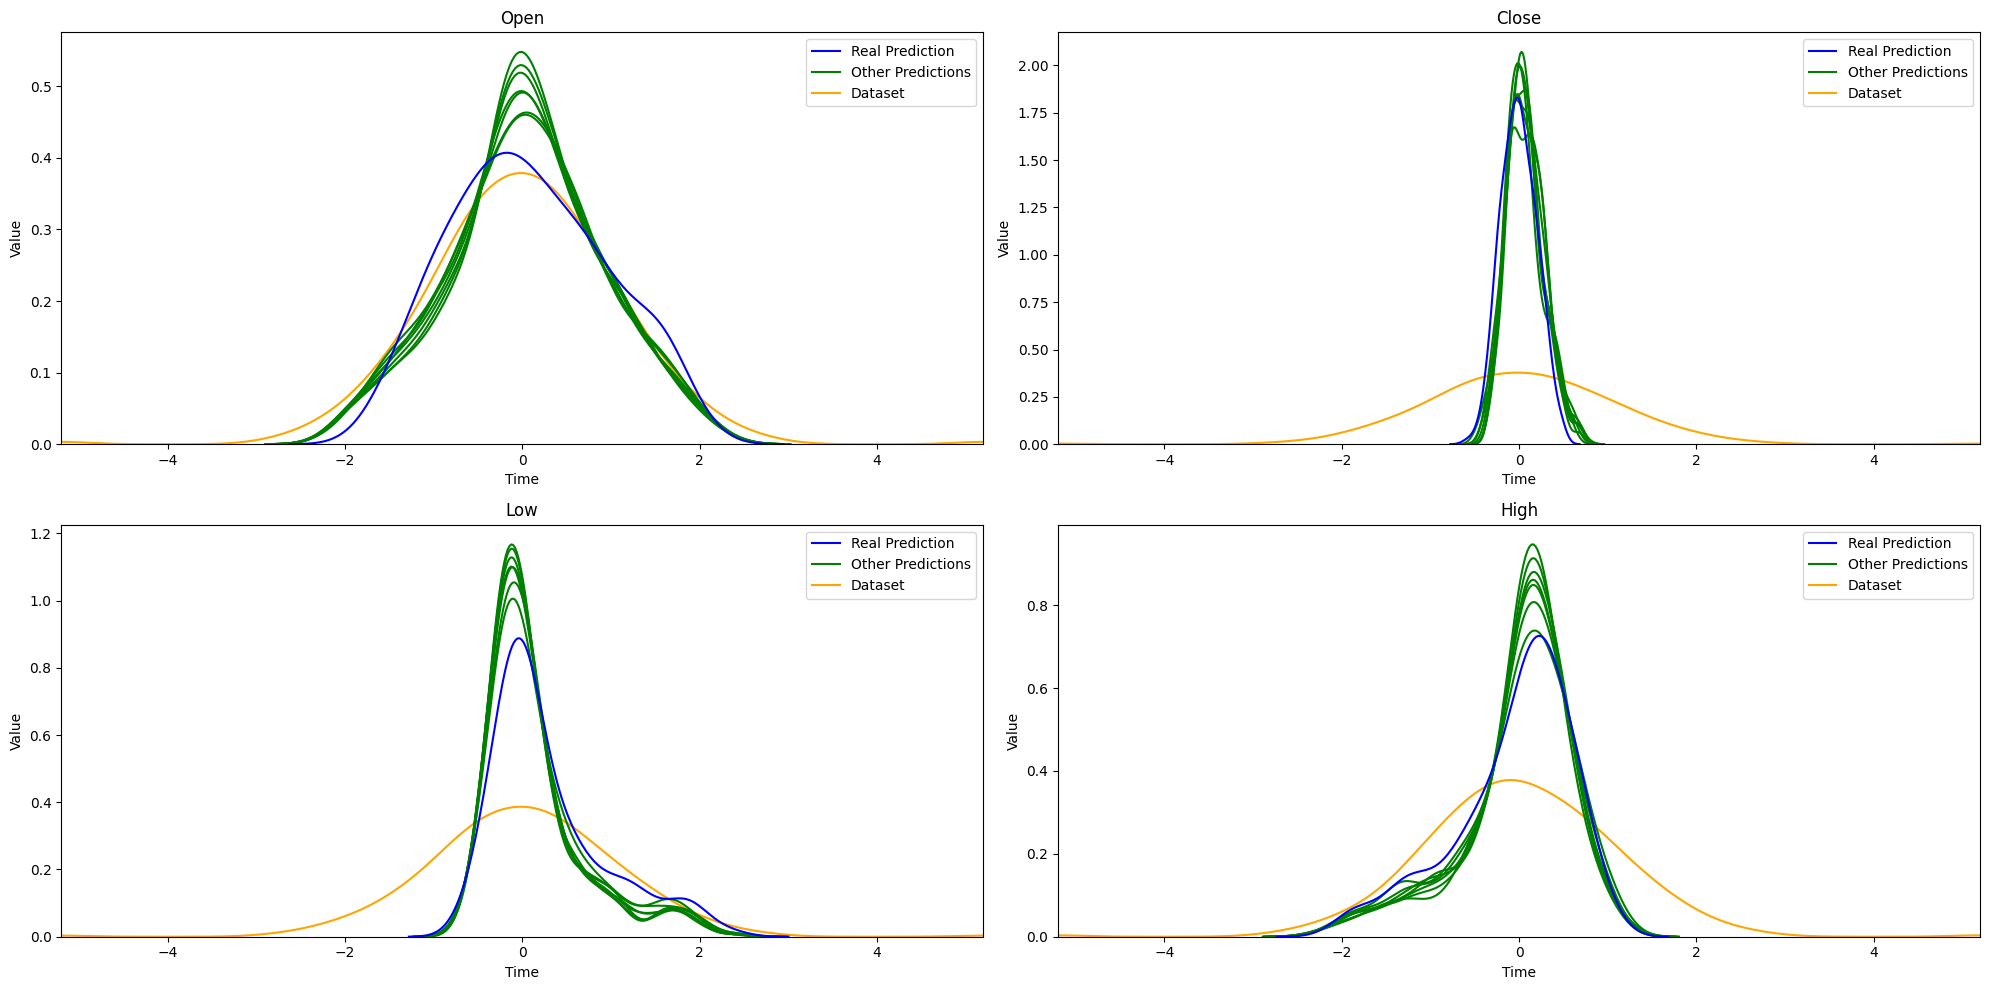

In [13]:
pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(train_pred_series.shape[0], trust), train_pred_series[:,:-1,trust], train_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    ground_truth = train_learned_dataframe_crop[inference_train_dataset.output_cols].values.T[i]
    sns.kdeplot(data=ground_truth, fill=False, color='orange', label='Dataset')
    for trust, pred_series_to_plot in reversed(list(enumerate(pred_series_with_different_trusts))):
        if trust == 0:
            sns.kdeplot(data=pred_series_to_plot[i], fill=False, color='blue', label='Real Prediction')
        else:
            sns.kdeplot(data=pred_series_to_plot[i], fill=False, color='green', label='Other Predictions')

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.xlim(ground_truth.min(), ground_truth.max())
    plt.ylabel("Value")
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

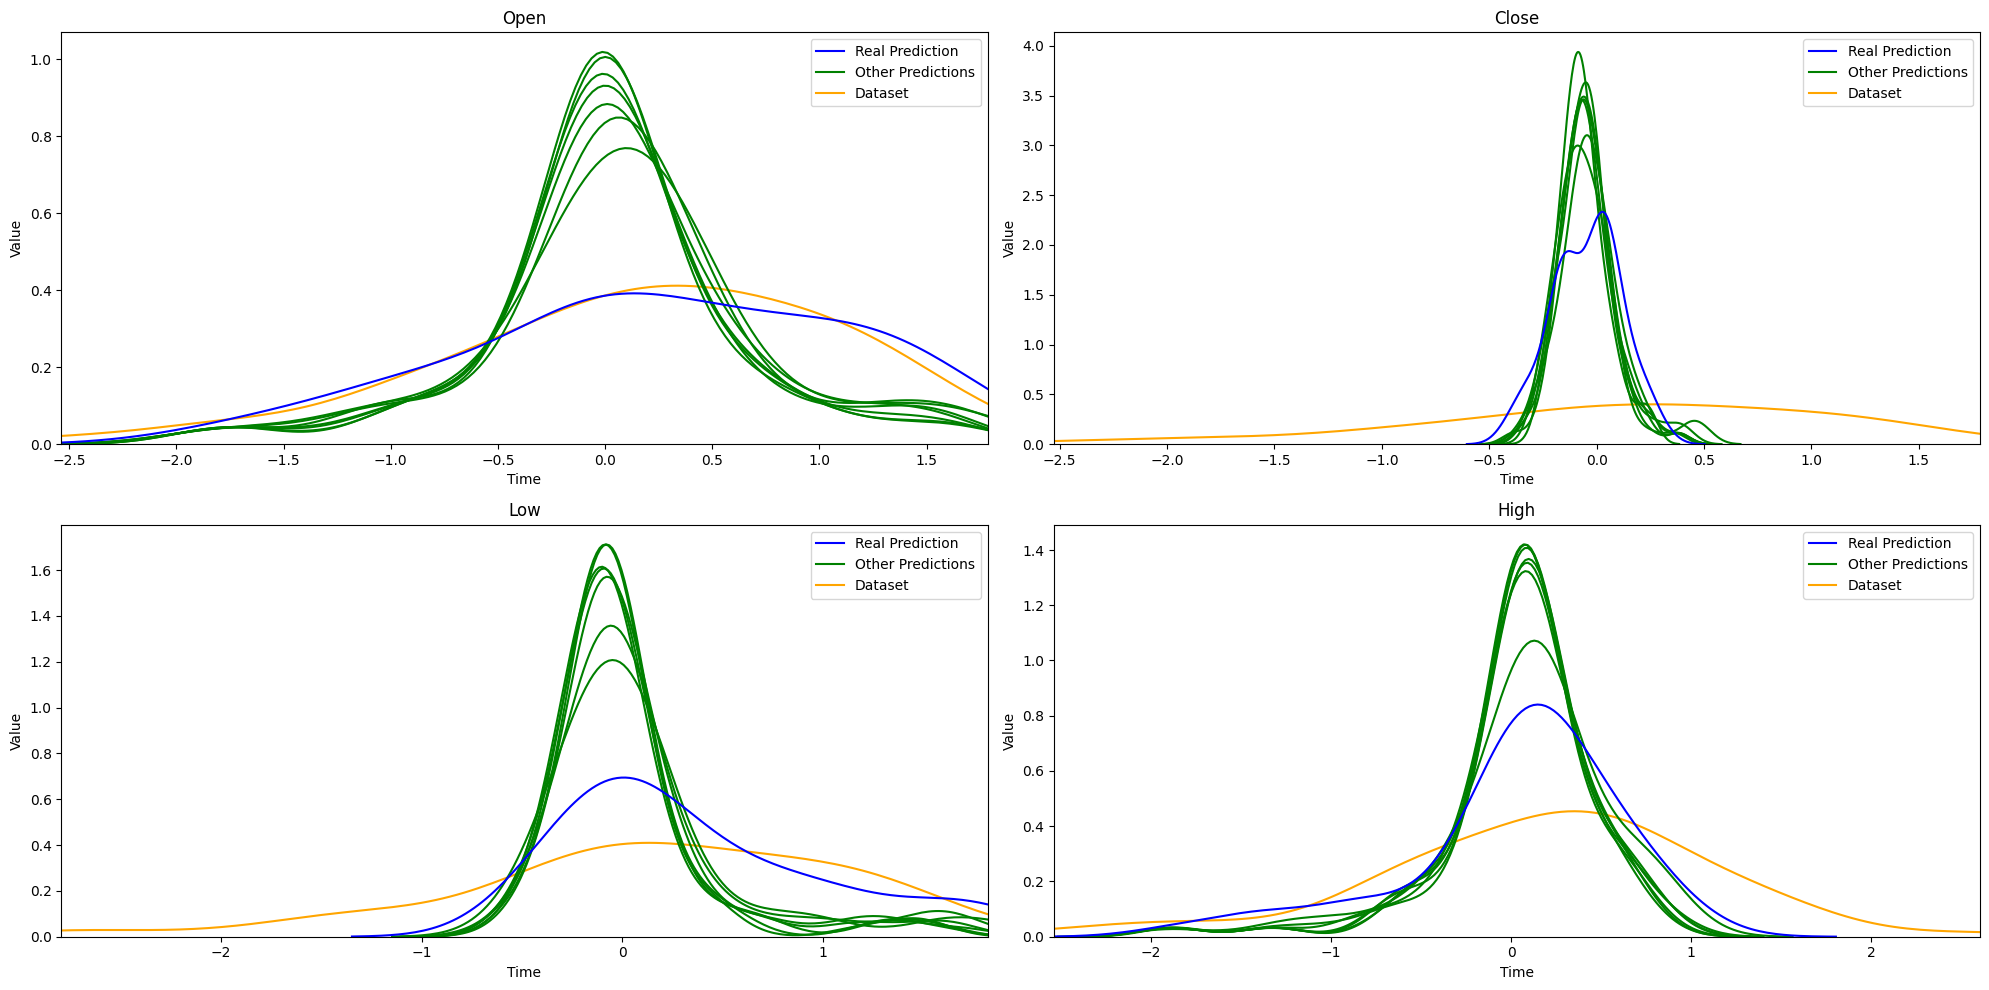

In [14]:
pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(val_pred_series.shape[0], trust), val_pred_series[:,:-1,trust], val_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    ground_truth = val_learned_dataframe_crop[inference_val_dataset.output_cols].values.T[i]
    sns.kdeplot(data=ground_truth, fill=False, color='orange', label='Dataset')
    for trust, pred_series_to_plot in reversed(list(enumerate(pred_series_with_different_trusts))):
        if trust == 0:
            sns.kdeplot(data=pred_series_to_plot[i], fill=False, color='blue', label='Real Prediction')
        else:
            sns.kdeplot(data=pred_series_to_plot[i], fill=False, color='green', label='Other Predictions')

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.xlim(ground_truth.min(), ground_truth.max())
    plt.ylabel("Value")
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

# Predictions on the real price

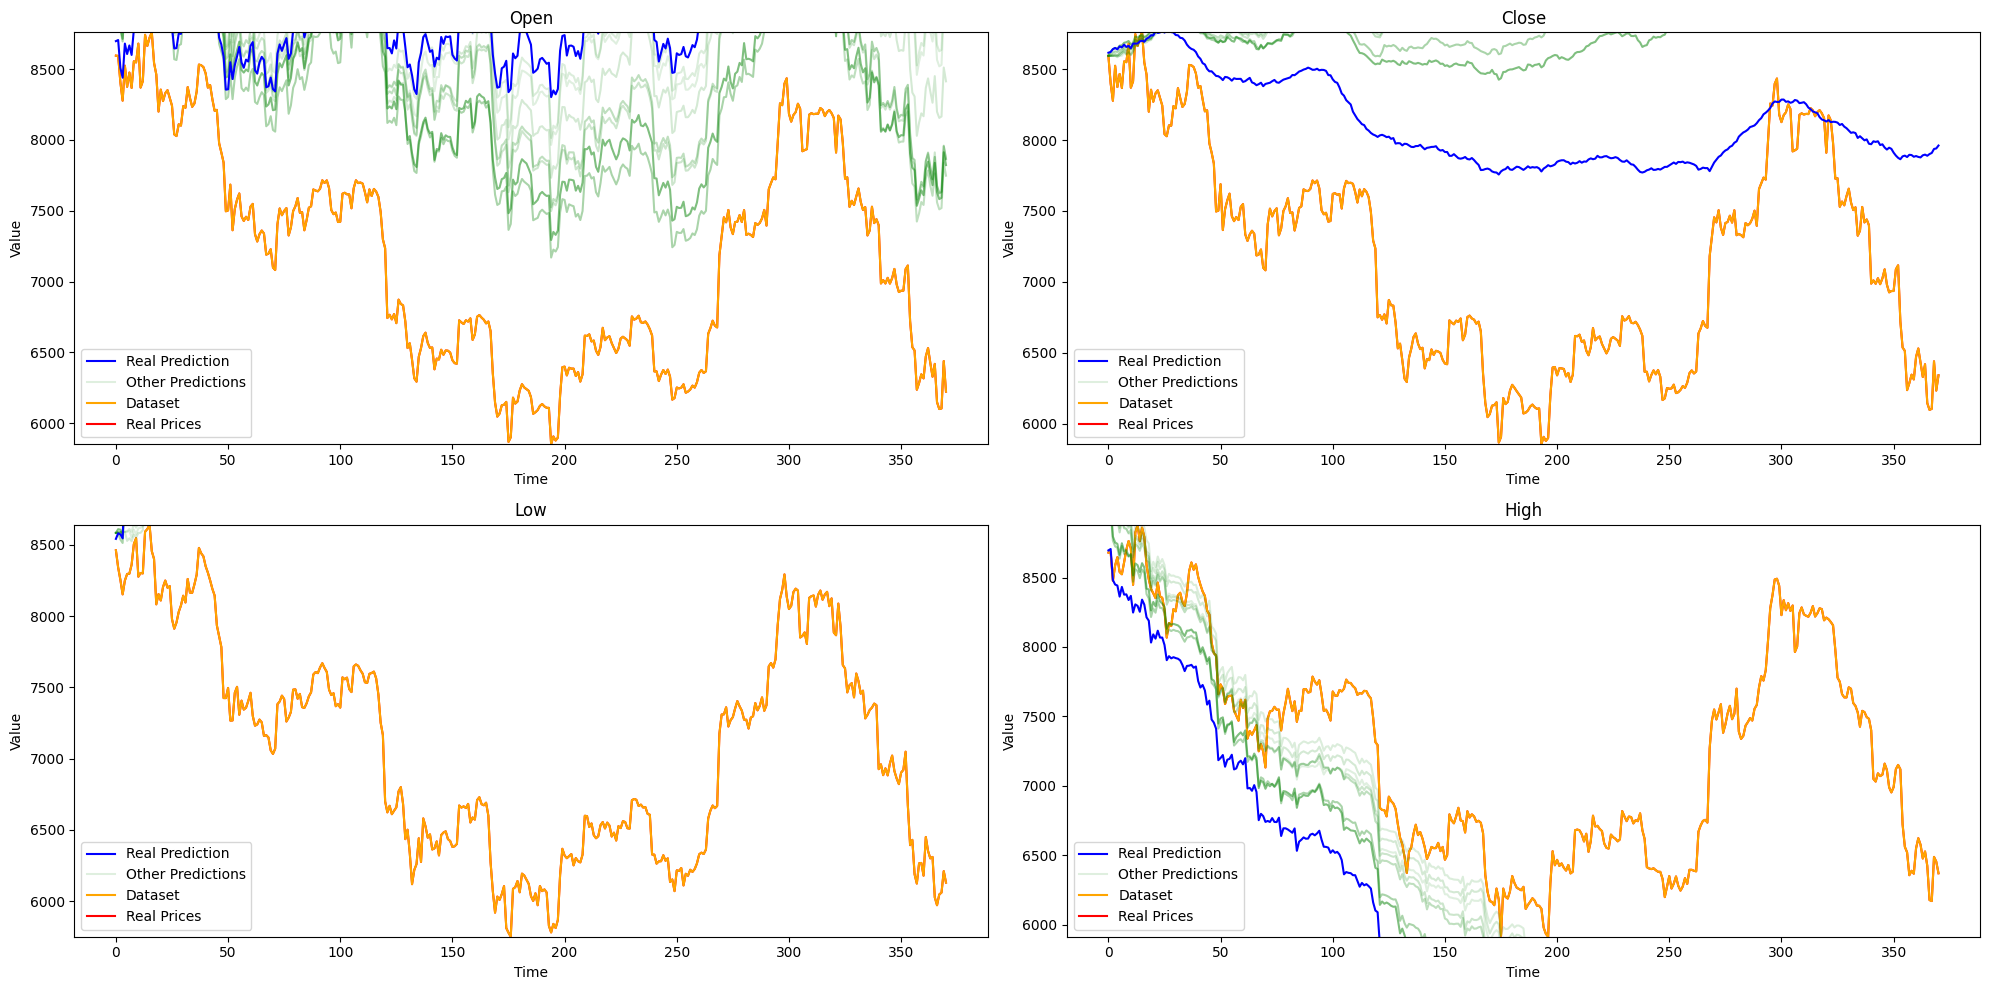

In [15]:
rescaled_target_series_to_plot = inference_val_dataset.rescale_to_real_price(train_learned_dataframe_crop[inference_val_dataset.output_cols].values, train_initial_prices).T

pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(train_pred_series.shape[0], trust), train_pred_series[:,:-1,trust], train_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    real_prices = train_df_preds[inference_val_dataset.output_cols].values.T[i]
    plt.plot(real_prices, label="Real Prices", color="red")

    ground_truth = rescaled_target_series_to_plot[i]
    plt.plot(ground_truth, label="Dataset", color="orange")
    for trust, pred_series_to_plot in reversed(list(enumerate(pred_series_with_different_trusts))):
        rescaled_pred_series_to_plot = inference_val_dataset.rescale_to_real_price(pred_series_to_plot.T, train_initial_prices).T
        if trust == 0:
            plt.plot(rescaled_pred_series_to_plot[i], label="Real Prediction", color="blue", alpha=1/(trust+1))
        else:
            plt.plot(rescaled_pred_series_to_plot[i], label="Other Predictions", color="green", alpha=1/(trust+1))

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.ylim(min(ground_truth.min(), real_prices.min()), max(ground_truth.max(), real_prices.max()))
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

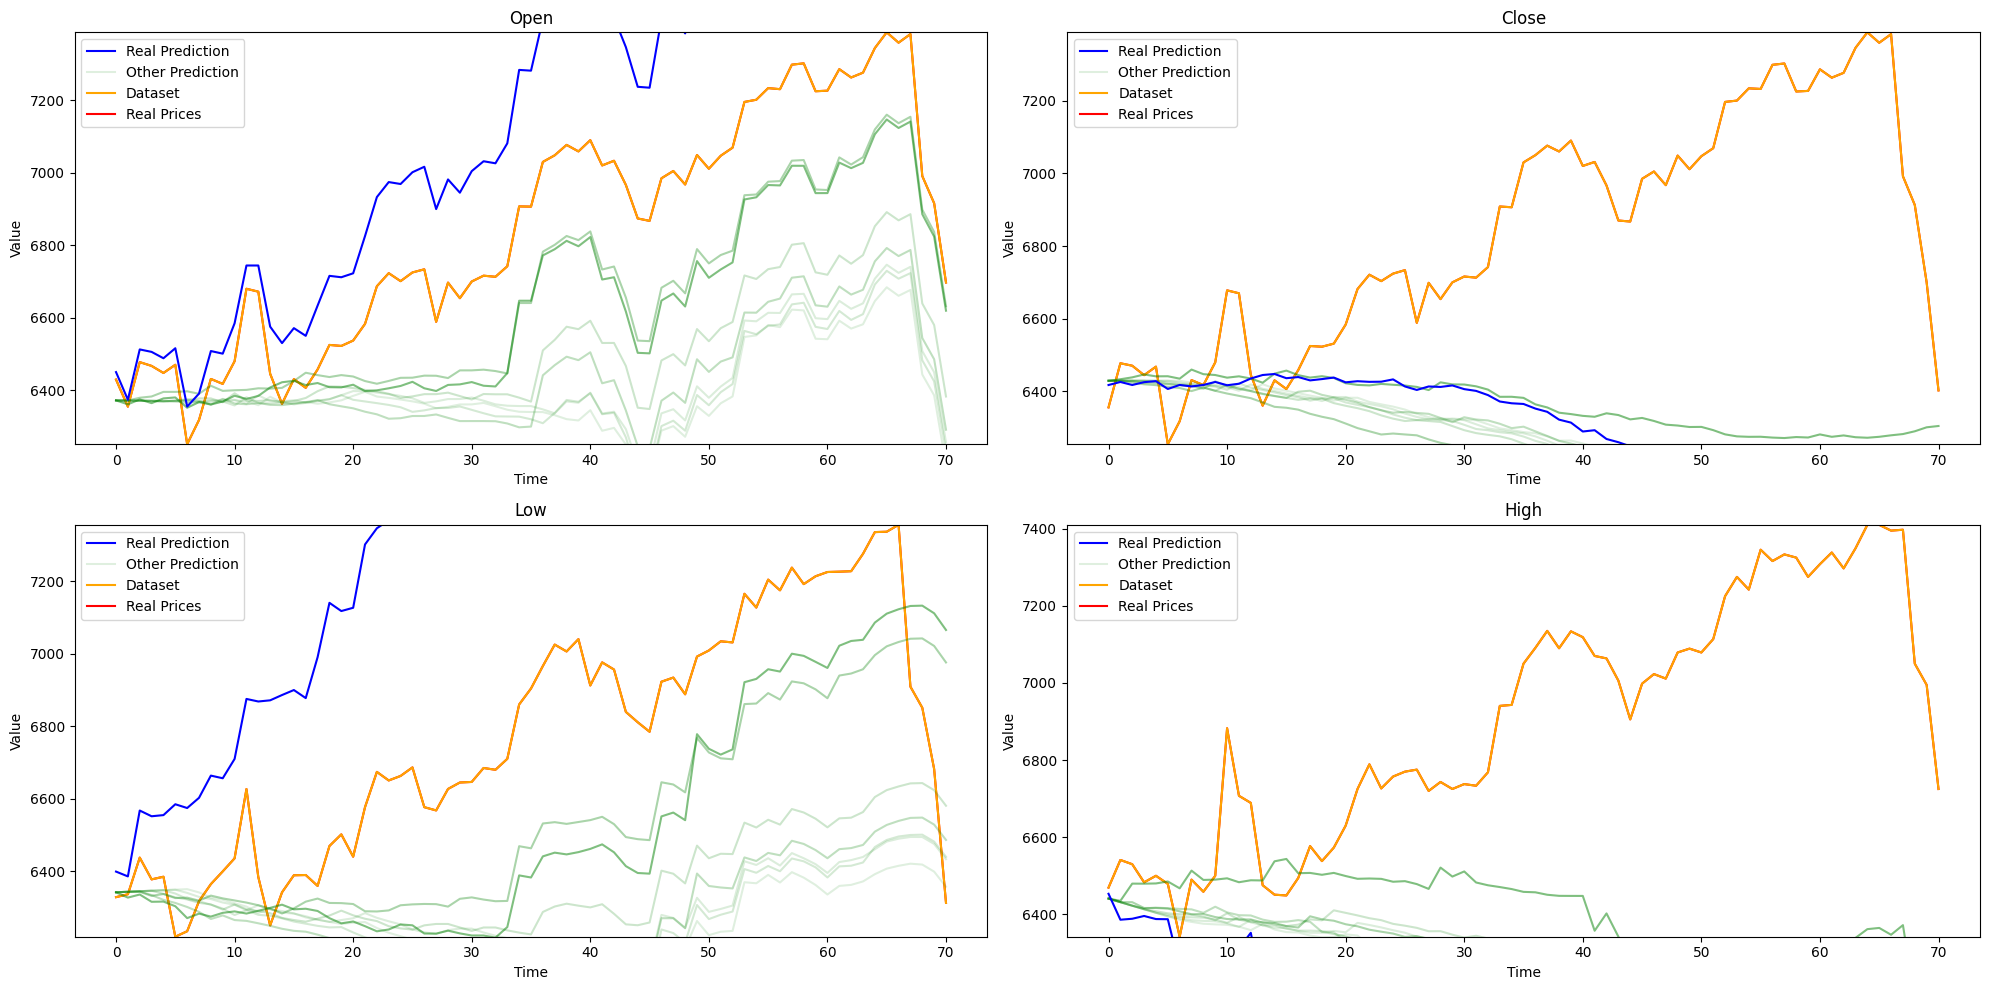

In [16]:
rescaled_target_series_to_plot = inference_val_dataset.rescale_to_real_price(val_learned_dataframe_crop[inference_val_dataset.output_cols].values, val_initial_prices).T

pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(val_pred_series.shape[0], trust), val_pred_series[:,:-1,trust], val_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    real_prices = val_df_preds[inference_val_dataset.output_cols].values.T[i]
    plt.plot(real_prices, label="Real Prices", color="red")

    ground_truth = rescaled_target_series_to_plot[i]
    plt.plot(ground_truth, label="Dataset", color="orange")
    for trust, pred_series_to_plot in reversed(list(enumerate(pred_series_with_different_trusts))):
        rescaled_pred_series_to_plot = inference_val_dataset.rescale_to_real_price(pred_series_to_plot.T, val_initial_prices).T
        if trust == 0:
            plt.plot(rescaled_pred_series_to_plot[i], label="Real Prediction", color="blue", alpha=1/(trust+1))
        else:
            plt.plot(rescaled_pred_series_to_plot[i], label="Other Prediction", color="green", alpha=1/(trust+1))
            
    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.ylim(min(ground_truth.min(), real_prices.min()), max(ground_truth.max(), real_prices.max()))
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()